# Pipeline organized in the Notebook

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

from src import io_transforms
from src import metrics

/Users/daniel.hosomi/csvd-projects/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load and Prepare Data

In [2]:
geo_dataset_formated = io_transforms.prepare_GEO_dataset("../../data/raw/GSE296007_RAW/", "../../data/interim/geo_dataset_formated.csv")

In [3]:
geo_dataset_formated.head()

,gene_id,MB1_1,MB100_2,MA1_2,MB1_3,MA1_1,MC1_2,MD1_3,MC100_1,CTR_3,...,CTR_1,MC1_3,MD1_1,MB100_3,MA100_2,MA1_3,MD1_2,MA100_1,MC100_3,MB1_2
0,ENSG00000000003,258,233,226,464,276,319,336,310,329,...,357,370,276,334,285,355,365,336,398,275
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,448,703,629,863,605,857,969,727,733,...,770,680,655,633,700,716,796,721,712,748
3,ENSG00000000457,23,40,33,37,26,17,47,41,31,...,27,27,42,44,31,35,38,30,67,32
4,ENSG00000000460,14,9,5,52,4,45,0,12,7,...,37,20,3,19,3,36,27,29,33,45


## Metrics with PyWGCNA

Starting WGCNA: Filtering top 10000 genes by MAD...
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  4473
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.465089  1.168517       0.783865  3013.875779  3102.572916   
1       2   0.01659 -0.184321        0.76671  1392.718883  1372.567073   
2       3  0.303396 -0.973041       0.819532   738.287297   686.339785   
3       4  0.489305 -1.337236        0.87324   427.974544   371.159517   
4       5  0.609341 -1.492254       0.912225   264.650679   213.535649   
5       6   0.68822 -1.586532       0.935835   171.967963   128.290916   
6       7  0.698355 -1.780234       0.926478   116.246231    79.580382   
7       8  0.726362 -1.869716       0.934703    81.166167     50.35363   
8       9  0.742008 -1.924363       0.940376    58.230067    32.855192   
9 

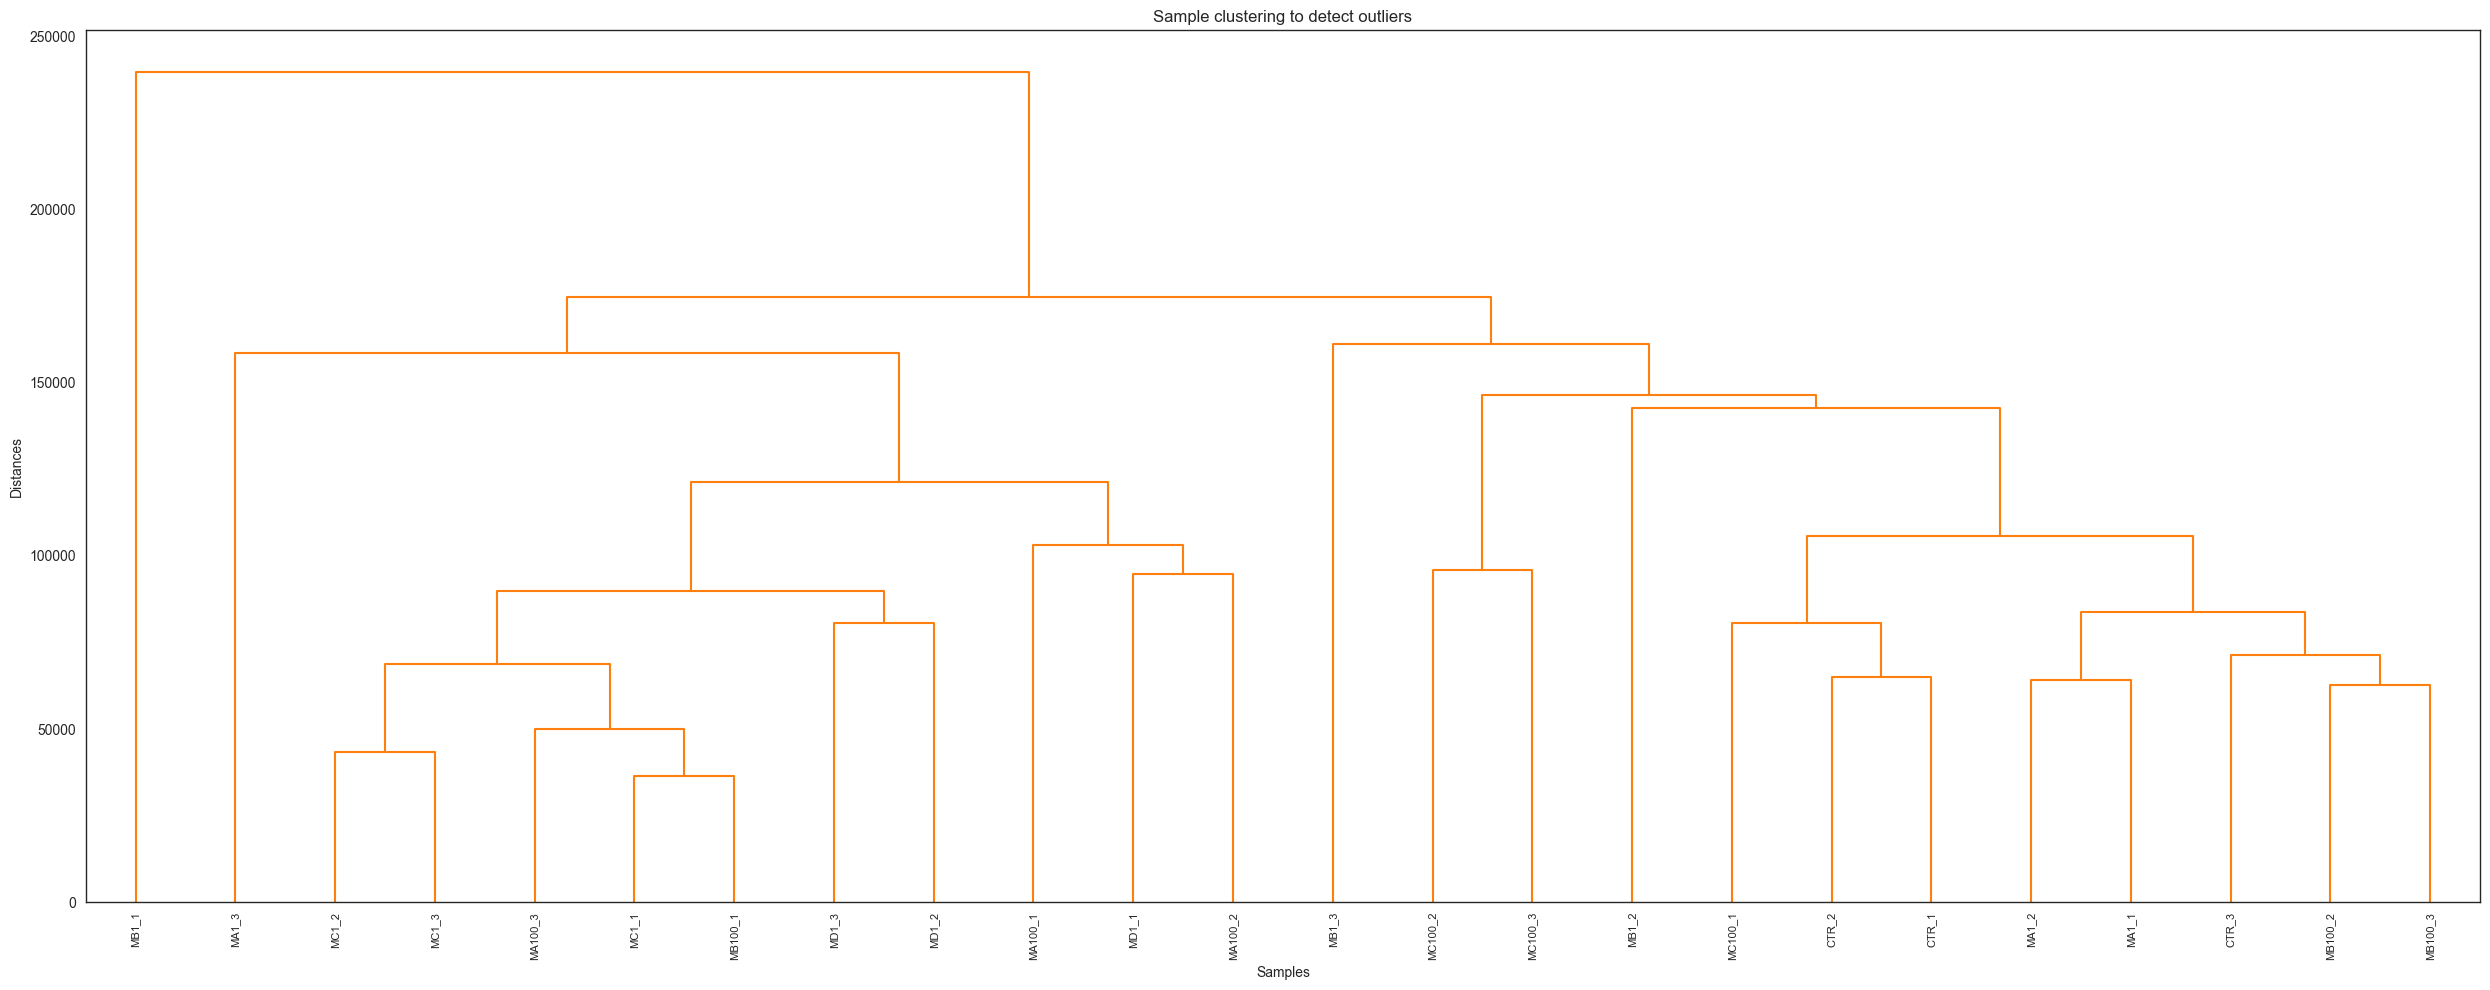

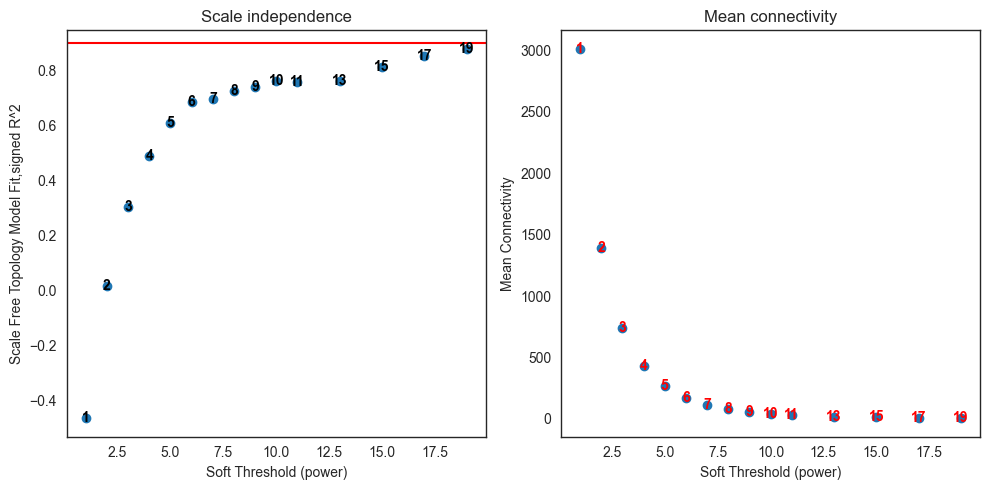

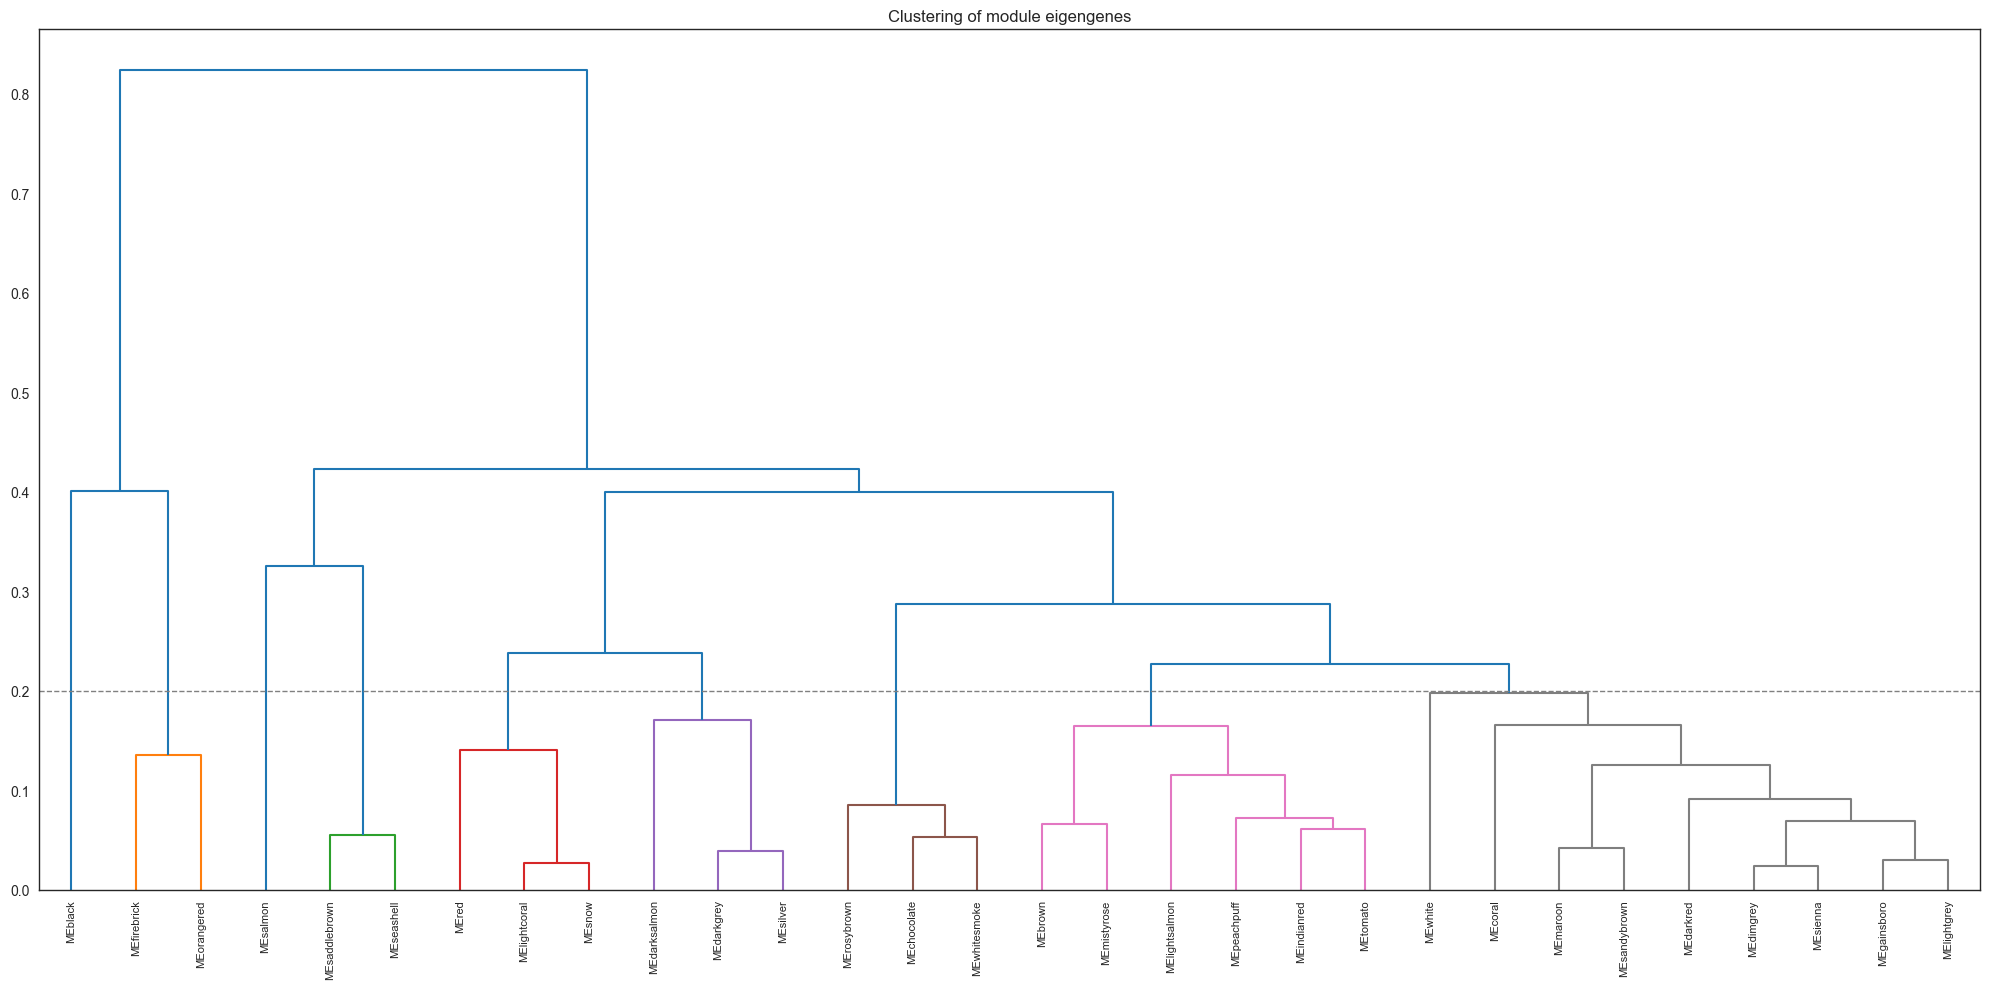

In [3]:
concentration_groups = {
    'MA1': '1 μm, 0.1 g/L',
    'MB1': '1 μm, 0.01 g/L',
    'MC1': '1 μm, 0.001 g/L',
    'MD1': '1 μm, 0.05 g/L',
    'MA100': '100 nm, 0.1 g/L',
    'MB100': '100 nm, 0.01 g/L',
    'MC100': '100 nm, 0.001 g/L'
}

wgcna_modules_dict = metrics.run_wgcna_pipeline(geo_dataset_formated, 10000, "../../data/interim/wgcna_df.csv", concentration_groups)

metrics.save_module_gene_ids(wgcna_modules_dict, "../../data/interim/wgcna_modules_csvs/")
print(wgcna_modules_dict)

## Metrics without PyWGCNA

In [26]:
concentration_groups = ['MA1', 'MB1', 'MC1', 'MD1', 'MA100', 'MB100', 'MC100']

for concentration in concentration_groups:
    log2fc_result = metrics.calculate_log2fc(geo_dataset_formated, treatment_group=concentration, control_group="CTR")
    filtered_genes = metrics.filter_significant_genes(log2fc_result, target_column=f"Log2FC_{concentration}", threshold=1.5, top_n=1900)
    
    print(f"Concentration: {concentration}, Significant Genes: {len(filtered_genes)}")
    save_path = f"../../data/interim/log2fc_filtered_results_{concentration}.csv"
    io_transforms.save_dataframe(filtered_genes['gene_id'], save_path)


Concentration: MA1, Significant Genes: 1900
Concentration: MB1, Significant Genes: 1900
Concentration: MC1, Significant Genes: 1900
Concentration: MD1, Significant Genes: 1900
Concentration: MA100, Significant Genes: 1900
Concentration: MB100, Significant Genes: 1900
Concentration: MC100, Significant Genes: 1900
